In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn import metrics 

from imblearn.over_sampling import SMOTE

In [14]:
df = pd.read_csv('../data/churn.csv', header='infer')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


## Feature Engineering

Binary columns

In [15]:
df.drop(['customerID'], axis=1, inplace=True)

In [17]:
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
# df = pd.get_dummies(df.gender, prefix='gender', drop_first=True).join(df.drop('gender', axis=1))

In [18]:
columnas_binarias = [
    col for col in df.select_dtypes(include=['object', 'category']).columns
     if df[col].nunique() == 2
]

for c in columnas_binarias:
    df[c] = df[c].map({'Yes': 1, 'No': 0})

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


Total charges

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [21]:
df['TotalCharges'].dtype
df['TotalCharges'].isna().sum()

np.int64(11)

In [22]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

df['TotalCharges'].isna().sum()

np.int64(0)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


Categorical columns

In [24]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## Model creation

In [26]:
X = df.drop('Churn', axis=1) 
y = df['Churn'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [37]:
# Modelo base
rfc = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Grid de parámetros más amplio
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, 50, 60, 70, None],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Búsqueda aleatoria con validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rfc,
    param_dist,
    n_iter=100,  # Aumentar iteraciones
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Entrenar
random_search.fit(X_train_resampled, y_train_resampled)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor score:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'gini', 'bootstrap': False}
Mejor score: 0.848485683996889


In [38]:
rfc_pred = random_search.predict(X_test)
print("Accuracy Random Forest Classifier:", f"{metrics.accuracy_score(y_test, rfc_pred)*100:.2f}%")
print(metrics.classification_report(y_test, rfc_pred))

Accuracy Random Forest Classifier: 76.58%
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1035
           1       0.55      0.61      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.77      0.77      1409



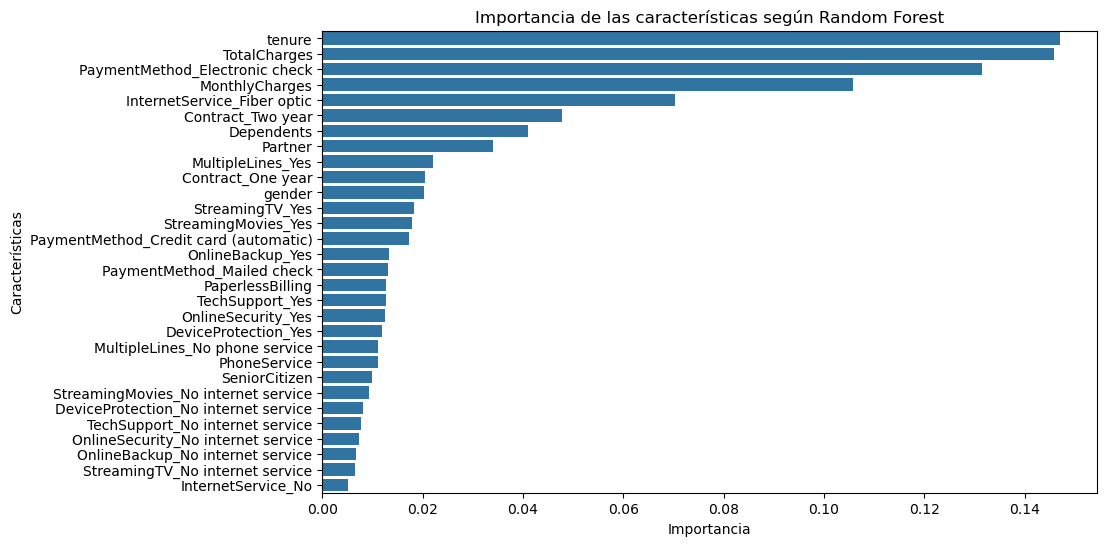

In [34]:
importancia_caracteristicas = pd.DataFrame(random_search.best_estimator_.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

Accuracy:  0.765791341376863
Precision:  0.5536585365853659
Recall:  0.606951871657754
F1 score:  0.5790816326530612
Confusion matriz:
 [[852 183]
 [147 227]]


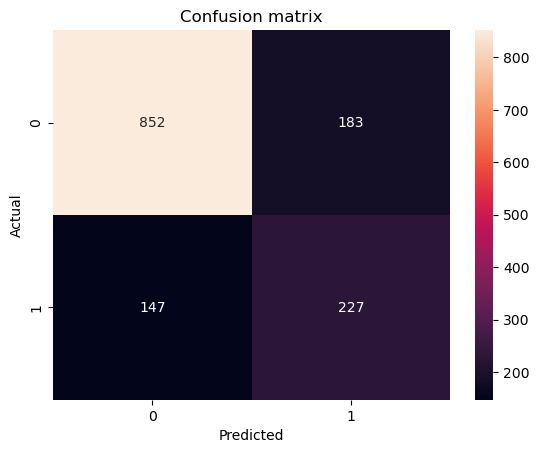

In [35]:
print("Accuracy: ", metrics.accuracy_score(y_test, rfc_pred))
print("Precision: ", metrics.precision_score(y_test, rfc_pred))
print("Recall: ", metrics.recall_score(y_test, rfc_pred))
print("F1 score: ", metrics.f1_score(y_test, rfc_pred))
matriz_confusion = metrics.confusion_matrix(y_test, rfc_pred)
print("Confusion matriz:\n", matriz_confusion)
sns.heatmap(matriz_confusion, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()